## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (asimetría, bordes irregulares, cambios de color/textura en lesiones).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets (como ImageNet) para mejorar rendimiento con menos datos.

## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos, y la **API de Kaggle** para descargar el dataset directamente al entorno (Colab o local).

### 2.1. Instalar dependencias

In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "kagglehub"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


### 2.2. Descargar el dataset desde Kaggle

Usamos `kagglehub`, que descarga el dataset directamente sin necesidad de subir manualmente `kaggle.json` en la mayoría de entornos (Colab detecta credenciales automáticamente si están configuradas; en local, debes tener `~/.kaggle/kaggle.json` con tu API token, generado desde kaggle.com/`<tu_usuario>`/account).

**Alternativa manual** (si `kagglehub` no funciona en tu entorno):
```python
!pip install -q kaggle
from google.colab import files
files.upload()  # sube tu kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
!unzip -q skin-cancer-malignant-vs-benign.zip -d skin_cancer_data
```

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print("Dataset descargado en:", dataset_path)


100%|██████████| 325M/325M [00:18<00:00, 18.2MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/fanconic/skin-cancer-malignant-vs-benign/versions/4


In [3]:
import os

# Exploramos la estructura de carpetas para ubicar train/test
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        continue


4/
  data/
    test/
      malignant/
      benign/
    train/
      malignant/
      benign/
  test/
    malignant/
    benign/
  train/
    malignant/
    benign/


## 3. Cargar el dataset médico (Skin Cancer: Malignant vs. Benign)

A diferencia de `medmnist` (que entrega arrays `.npz` ya empaquetados), aquí las imágenes vienen como **archivos `.jpg` organizados en carpetas por clase**. Usamos `torchvision.datasets.ImageFolder`, que lee automáticamente la estructura `train/benign`, `train/malignant`, `test/benign`, `test/malignant` y asigna las etiquetas según el nombre de la carpeta.

Características del dataset en este ejercicio:
- Entrada: imágenes dermatoscópicas a color, tamaños variables (las redimensionamos nosotros).
- Etiquetas: clasificación binaria (`benign` = 0, `malignant` = 1).
- Particiones: `train` y `test` ya vienen definidas; nosotros separamos una porción de `train` para `val`.

In [4]:
# Ajusta estas rutas según lo que haya mostrado el listado de carpetas de arriba
# Normalmente la estructura es: <dataset_path>/train y <dataset_path>/test
train_dir_candidates = [os.path.join(dataset_path, "train"), os.path.join(dataset_path, "data", "train")]
test_dir_candidates  = [os.path.join(dataset_path, "test"),  os.path.join(dataset_path, "data", "test")]

train_dir = next(p for p in train_dir_candidates if os.path.isdir(p))
test_dir  = next(p for p in test_dir_candidates  if os.path.isdir(p))

print("train_dir:", train_dir)
print("test_dir: ", test_dir)
print("Clases encontradas:", os.listdir(train_dir))


train_dir: /root/.cache/kagglehub/datasets/fanconic/skin-cancer-malignant-vs-benign/versions/4/train
test_dir:  /root/.cache/kagglehub/datasets/fanconic/skin-cancer-malignant-vs-benign/versions/4/test
Clases encontradas: ['malignant', 'benign']


In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from tqdm import tqdm

data_flag = "skin_cancer_malignant_vs_benign"
IMG_SIZE = 64  # tamaño chico (estilo MedMNIST) para que el entrenamiento sea rápido

transform_basic = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

full_train_dataset = ImageFolder(train_dir, transform=transform_basic)
test_dataset = ImageFolder(test_dir, transform=transform_basic)

# medmnist trae val ya separado; aquí lo creamos nosotros a partir del train (85% train / 15% val)
val_frac = 0.15
val_size = int(len(full_train_dataset) * val_frac)
train_size = len(full_train_dataset) - val_size

g = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=g)

class_to_idx = full_train_dataset.class_to_idx
print("class_to_idx:", class_to_idx)
len(train_dataset), len(val_dataset), len(test_dataset)


class_to_idx: {'benign': 0, 'malignant': 1}


(2242, 395, 660)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.

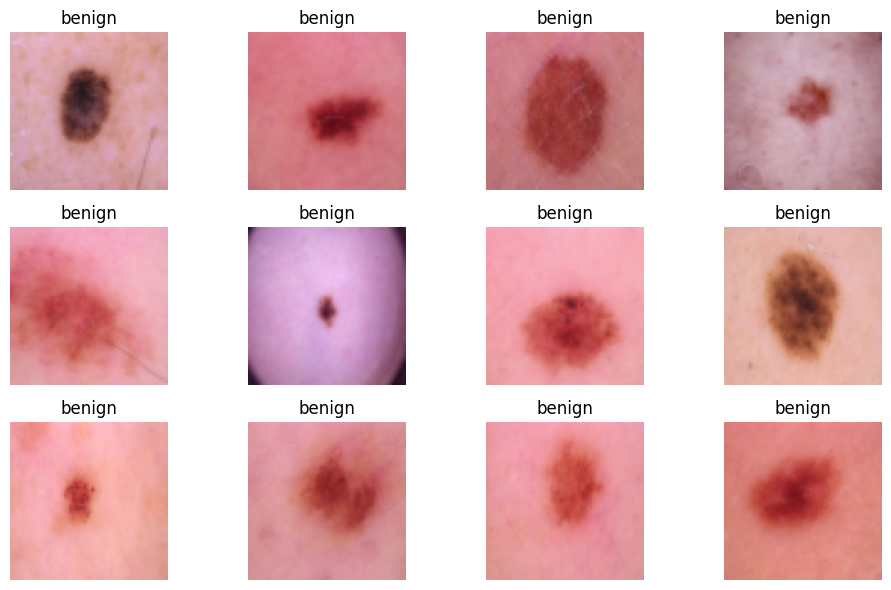

In [6]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 6))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.permute(1, 2, 0).numpy()  # C,H,W -> H,W,C para imágenes a color
        plt.imshow(img)
        plt.title(idx_to_class[int(y)])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(full_train_dataset, n=12)


### 3.2. Distribución de clases

En salud es clave revisar el balance de clases: si hay muchos más benignos que malignos (o viceversa), el modelo puede sesgarse.

Distribución de clases en train: {'benign': 1440, 'malignant': 1197}


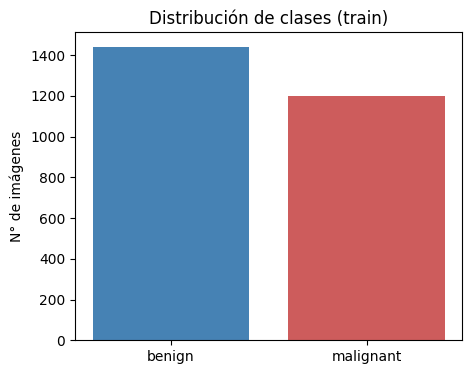

In [7]:
from collections import Counter

labels_all = [y for _, y in full_train_dataset.samples]
counts = Counter(labels_all)
counts_named = {idx_to_class[k]: v for k, v in counts.items()}
print("Distribución de clases en train:", counts_named)

plt.figure(figsize=(5, 4))
plt.bar(counts_named.keys(), counts_named.values(), color=["steelblue", "indianred"])
plt.title("Distribución de clases (train)")
plt.ylabel("N° de imágenes")
plt.show()


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [9]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([64, 3, 64, 64]), torch.Size([64]))

## 5. Modelo 1: CNN entrenada desde cero

Construimos una CNN base con bloques conv + BatchNorm + ReLU + pooling, y Dropout antes del clasificador final. Usamos 32, 64 y 128 filtros en las tres capas convolucionales (en vez de un número menor), ya que con más filtros el modelo puede aprender más patrones distintos en cada capa.

- **BatchNorm** normaliza las activaciones dentro de la red, lo que estabiliza y acelera el entrenamiento.
- **Dropout** apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento, lo que ayuda a reducir el sobreajuste (overfitting).

Las imágenes son a color (3 canales RGB), así que la primera convolución recibe 3 canales de entrada en vez de 1.

In [10]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(class_to_idx)  # 2: benign, malignant

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, dropout_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 canales (RGB) en vez de 1 (grises)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

`evaluate` recibe opcionalmente el `criterion` para calcular también la pérdida (loss) de validación/test, además de las métricas anteriores — así podemos graficar `train_loss` junto a `val_loss` y detectar sobreajuste.

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()  # ImageFolder ya entrega shape correcto (sin squeeze)

        logits = model(x)

        if criterion is not None:
            loss = criterion(logits, y)
            losses.append(loss.item())

        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    avg_loss = float(np.mean(losses)) if losses else None
    return acc, auc, y_true, y_pred, y_prob, avg_loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

### 5.2. Entrenar el modelo desde cero (con scheduler de learning rate)

Entrenamos durante 20 épocas. En vez de un learning rate fijo durante todo el entrenamiento, usamos un **scheduler** (`StepLR`): cada 5 épocas, el learning rate se reduce a la mitad. La idea es que al inicio el modelo aprenda con pasos más grandes y, conforme avanza el entrenamiento, dé pasos más pequeños para afinar mejor la convergencia.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

# Cada 5 épocas, el learning rate se reduce a la mitad (gamma=0.5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 20
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader, criterion)
    current_lr = optimizer.param_groups[0]["lr"]

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["lr"].append(current_lr)

    print(f"Epoch {epoch:02d} | lr={current_lr:.6f} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    scheduler.step()  # actualiza el learning rate al final de cada época


Epoch 01 | lr=0.001000 | train_loss=0.4429 | val_loss=0.4950 | val_acc=0.7443 | val_auc=0.8455
Epoch 02 | lr=0.001000 | train_loss=0.4044 | val_loss=0.5614 | val_acc=0.7418 | val_auc=0.8600
Epoch 03 | lr=0.001000 | train_loss=0.4006 | val_loss=0.7990 | val_acc=0.6354 | val_auc=0.8359
Epoch 04 | lr=0.001000 | train_loss=0.3921 | val_loss=0.4632 | val_acc=0.7696 | val_auc=0.8686
Epoch 05 | lr=0.001000 | train_loss=0.3909 | val_loss=0.5499 | val_acc=0.7544 | val_auc=0.8356
Epoch 06 | lr=0.000500 | train_loss=0.3625 | val_loss=0.4456 | val_acc=0.7949 | val_auc=0.8789
Epoch 07 | lr=0.000500 | train_loss=0.3661 | val_loss=0.4776 | val_acc=0.7747 | val_auc=0.8624
Epoch 08 | lr=0.000500 | train_loss=0.3516 | val_loss=0.4375 | val_acc=0.8025 | val_auc=0.8813
Epoch 09 | lr=0.000500 | train_loss=0.3408 | val_loss=0.5758 | val_acc=0.7316 | val_auc=0.8655
Epoch 10 | lr=0.000500 | train_loss=0.3636 | val_loss=0.4212 | val_acc=0.8000 | val_auc=0.8870
Epoch 11 | lr=0.000250 | train_loss=0.3490 | val_l

### 5.3. Curvas de entrenamiento

Visualizamos pérdida de entrenamiento vs. validación (para detectar sobreajuste) y la evolución del learning rate a lo largo de las épocas.

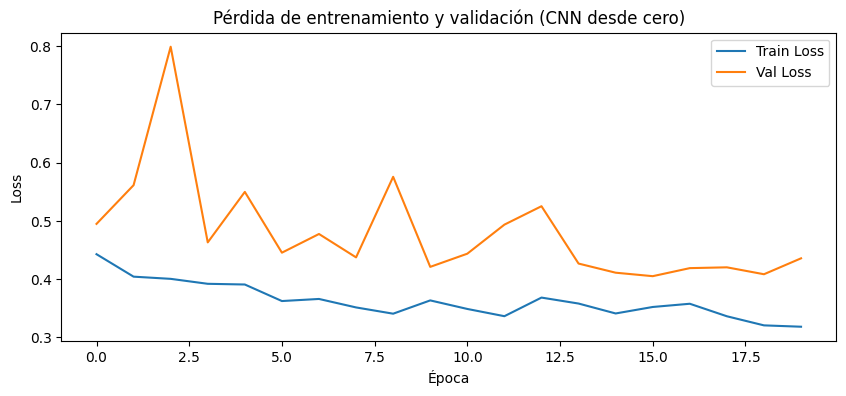

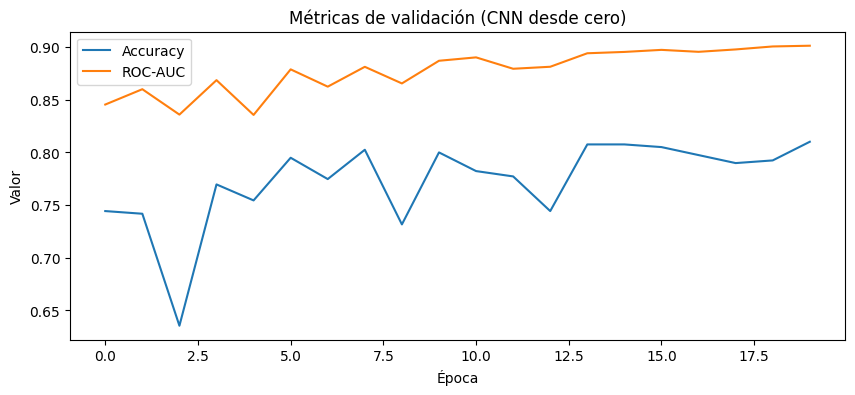

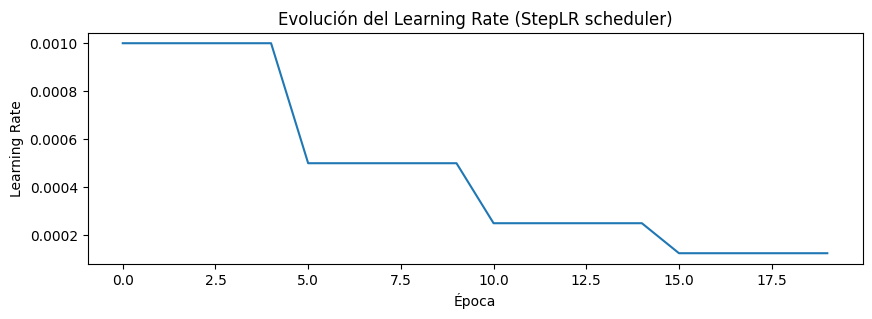

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss")
plt.plot(history_scratch["val_loss"], label="Val Loss")
plt.title("Pérdida de entrenamiento y validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(history_scratch["lr"])
plt.title("Evolución del Learning Rate (StepLR scheduler)")
plt.xlabel("Época")
plt.ylabel("Learning Rate")
plt.show()


### 5.4. Evaluación final en test

In [14]:
test_acc, test_auc, y_true, y_pred, y_prob, _ = evaluate(model_scratch, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4, target_names=list(class_to_idx.keys())))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8258
Test ROC-AUC:  0.9267

              precision    recall  f1-score   support

      benign     0.9455    0.7222    0.8189       360
   malignant     0.7403    0.9500    0.8321       300

    accuracy                         0.8258       660
   macro avg     0.8429    0.8361    0.8255       660
weighted avg     0.8522    0.8258    0.8249       660



array([[260, 100],
       [ 15, 285]])

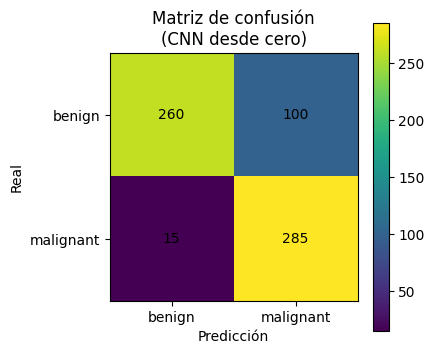

In [15]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión\n(CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1], list(class_to_idx.keys()))
plt.yticks([0, 1], list(class_to_idx.keys()))
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


### 5.5. Curva ROC

La curva ROC muestra el trade-off entre sensibilidad (recall) y tasa de falsos positivos a distintos umbrales de decisión — útil para elegir el umbral según el contexto clínico.

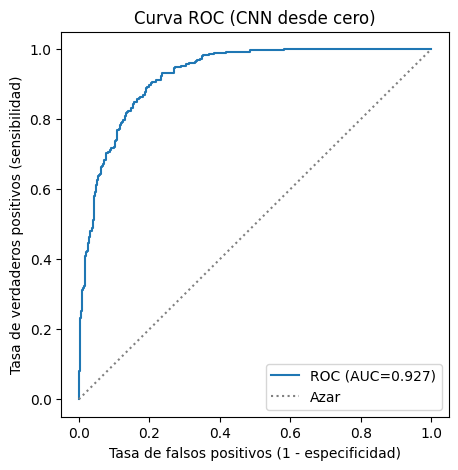

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC={test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos (1 - especificidad)")
plt.ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.title("Curva ROC (CNN desde cero)")
plt.legend()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- En lesiones de piel, los volteos horizontales/verticales sí suelen ser válidos (a diferencia de una radiografía de tórax, una lesión en la piel no tiene una orientación anatómica fija).

Para analizar el impacto de distintos niveles de aumento, comparamos dos configuraciones:
- **Light:** solo una rotación leve.
- **Heavy:** rotación más fuerte, flips horizontales/verticales y variaciones de color más agresivas.

In [17]:
# Configuración A: augmentation suave (solo rotación leve)
transform_aug_light = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=5),
    T.ToTensor()
])

# Configuración B: augmentation fuerte (rotación + flips + color jitter agresivo)
transform_aug_heavy = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=30),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    T.ToTensor()
])

full_train_light = ImageFolder(train_dir, transform=transform_aug_light)
full_train_heavy = ImageFolder(train_dir, transform=transform_aug_heavy)

# usamos los mismos índices que train_dataset (vía random_split) para mantener el mismo split
train_dataset_light = torch.utils.data.Subset(full_train_light, train_dataset.indices)
train_dataset_heavy = torch.utils.data.Subset(full_train_heavy, train_dataset.indices)

train_loader_light = DataLoader(train_dataset_light, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
train_loader_heavy = DataLoader(train_dataset_heavy, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


### 6.1. Entrenar un modelo con cada nivel de augmentation

Usamos la misma arquitectura (`SimpleCNN`, con BatchNorm y Dropout) para que la comparación sea justa, y entrenamos un modelo con cada configuración de aumento de datos.

In [18]:
def train_and_evaluate(model, train_loader_x, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader_x, optimizer, criterion)
        val_acc, val_auc, _, _, _, val_loss = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    return history

print("Entrenando con augmentation LIGHT...")
model_light = SimpleCNN(num_classes=num_classes).to(device)
history_light = train_and_evaluate(model_light, train_loader_light)

print("\nEntrenando con augmentation HEAVY...")
model_heavy = SimpleCNN(num_classes=num_classes).to(device)
history_heavy = train_and_evaluate(model_heavy, train_loader_heavy)

# Este es el modelo "con augmentation" que se usará más adelante (sección 7) al comparar
# contra el modelo sin augmentation y el de transfer learning; usamos la versión heavy.
model_aug = model_heavy


Entrenando con augmentation LIGHT...
Epoch 01 | train_loss=0.4611 | val_loss=0.8708 | val_acc=0.6228 | val_auc=0.8368
Epoch 02 | train_loss=0.4217 | val_loss=0.5082 | val_acc=0.7241 | val_auc=0.8700
Epoch 03 | train_loss=0.3769 | val_loss=0.5785 | val_acc=0.7418 | val_auc=0.8664
Epoch 04 | train_loss=0.3701 | val_loss=0.4820 | val_acc=0.7696 | val_auc=0.8719
Epoch 05 | train_loss=0.3721 | val_loss=0.4678 | val_acc=0.7747 | val_auc=0.8770
Epoch 06 | train_loss=0.3707 | val_loss=0.6993 | val_acc=0.7165 | val_auc=0.8707
Epoch 07 | train_loss=0.3812 | val_loss=0.8164 | val_acc=0.6658 | val_auc=0.8499
Epoch 08 | train_loss=0.4255 | val_loss=0.4762 | val_acc=0.7848 | val_auc=0.8677
Epoch 09 | train_loss=0.3908 | val_loss=0.6196 | val_acc=0.7392 | val_auc=0.8656
Epoch 10 | train_loss=0.3592 | val_loss=0.5327 | val_acc=0.7544 | val_auc=0.8704
Epoch 11 | train_loss=0.3677 | val_loss=0.5155 | val_acc=0.7873 | val_auc=0.8679
Epoch 12 | train_loss=0.3643 | val_loss=0.5227 | val_acc=0.7544 | val_au

### 6.2. Comparación del impacto de cada nivel de augmentation

Comparación de estrategias de data augmentation
Sin augmentation     | test_acc=0.8258       | test_auc=0.9267
Augmentation light   | test_acc=0.7879 | test_auc=0.9064
Augmentation heavy   | test_acc=0.7848   | test_auc=0.9036


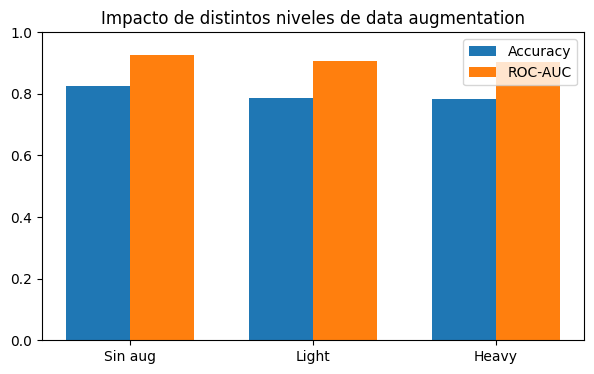

In [19]:
test_acc_light, test_auc_light, _, _, _, _ = evaluate(model_light, test_loader, criterion)
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_heavy, test_loader, criterion)

print("Comparación de estrategias de data augmentation")
print(f"Sin augmentation     | test_acc={test_acc:.4f}       | test_auc={test_auc:.4f}")
print(f"Augmentation light   | test_acc={test_acc_light:.4f} | test_auc={test_auc_light:.4f}")
print(f"Augmentation heavy   | test_acc={test_acc_aug:.4f}   | test_auc={test_auc_aug:.4f}")

labels_plot = ["Sin aug", "Light", "Heavy"]
accs = [test_acc, test_acc_light, test_acc_aug]
aucs = [test_auc, test_auc_light, test_auc_aug]

x = np.arange(len(labels_plot))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, aucs, width, label="ROC-AUC")
plt.xticks(x, labels_plot)
plt.ylim(0, 1)
plt.title("Impacto de distintos niveles de data augmentation")
plt.legend()
plt.show()


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

En este caso, como nuestras imágenes **ya son a color (3 canales)**, no necesitamos repetir el canal como en el notebook base (que trabajaba con escala de grises). Solo redimensionamos al tamaño típico de ResNet (224x224) y normalizamos.

In [20]:
import torchvision.models as models

# Normalización estándar de ImageNet, recomendada al usar pesos preentrenados
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=15),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std)
])

full_train_dataset_tl = ImageFolder(train_dir, transform=transform_tl_train)
train_dataset_tl = torch.utils.data.Subset(full_train_dataset_tl, train_dataset.indices)

full_val_dataset_tl = ImageFolder(train_dir, transform=transform_tl_eval)
val_dataset_tl = torch.utils.data.Subset(full_val_dataset_tl, val_dataset.indices)

test_dataset_tl = ImageFolder(test_dir, transform=transform_tl_eval)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([32, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.

In [21]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 12
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.5213 | val_loss=0.4228 | val_acc=0.7899 | val_auc=0.8841
Stage1 Epoch 02 | train_loss=0.3857 | val_loss=0.4459 | val_acc=0.8203 | val_auc=0.8959
Stage1 Epoch 03 | train_loss=0.3621 | val_loss=0.4236 | val_acc=0.8177 | val_auc=0.9021
Stage1 Epoch 04 | train_loss=0.3466 | val_loss=0.4114 | val_acc=0.8228 | val_auc=0.9051
Stage1 Epoch 05 | train_loss=0.3585 | val_loss=0.4340 | val_acc=0.8127 | val_auc=0.9070
Stage1 Epoch 06 | train_loss=0.3822 | val_loss=0.4081 | val_acc=0.8228 | val_auc=0.9076
Stage1 Epoch 07 | train_loss=0.3733 | val_loss=0.4556 | val_acc=0.8152 | val_auc=0.9082
Stage1 Epoch 08 | train_loss=0.3469 | val_loss=0.4071 | val_acc=0.8177 | val_auc=0.9087
Stage1 Epoch 09 | train_loss=0.3313 | val_loss=0.4627 | val_acc=0.8051 | val_auc=0.9048
Stage1 Epoch 10 | train_loss=0.3438 | val_loss=0.3984 | val_acc=0.8101 | val_auc=0.9080
Stage1 Epoch 11 | train_loss=0.3428 | val_loss=0.4038 | val_acc=0.8152 | val_auc=0.9070
Stage1 Epoch 12 | train_loss=0.3

### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.

In [23]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [24]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 8
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl, criterion)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.3316 | val_loss=0.3437 | val_acc=0.8734 | val_auc=0.9379
Stage2 Epoch 02 | train_loss=0.2141 | val_loss=0.3697 | val_acc=0.8405 | val_auc=0.9353
Stage2 Epoch 03 | train_loss=0.1852 | val_loss=0.4751 | val_acc=0.8557 | val_auc=0.9428
Stage2 Epoch 04 | train_loss=0.1967 | val_loss=0.3548 | val_acc=0.8759 | val_auc=0.9503
Stage2 Epoch 05 | train_loss=0.1154 | val_loss=0.4272 | val_acc=0.8785 | val_auc=0.9483
Stage2 Epoch 06 | train_loss=0.0895 | val_loss=0.4014 | val_acc=0.8684 | val_auc=0.9529
Stage2 Epoch 07 | train_loss=0.1141 | val_loss=0.3704 | val_acc=0.8835 | val_auc=0.9549
Stage2 Epoch 08 | train_loss=0.0964 | val_loss=0.4323 | val_acc=0.8810 | val_auc=0.9499


### 7.3. Evaluación en test del modelo con transfer learning

In [25]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl, criterion)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4, target_names=list(class_to_idx.keys())))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8803 | test_auc=0.9583

              precision    recall  f1-score   support

      benign     0.9026    0.8750    0.8886       360
   malignant     0.8553    0.8867    0.8707       300

    accuracy                         0.8803       660
   macro avg     0.8789    0.8808    0.8796       660
weighted avg     0.8811    0.8803    0.8805       660



array([[315,  45],
       [ 34, 266]])

### 7.4. Comparación global (resumen)

Resumen de resultados en test
CNN desde cero (sin aug)   | acc=0.8258 | auc=0.9267
CNN desde cero (con aug)   | acc=0.7848 | auc=0.9036
Transfer learning (ResNet) | acc=0.8803 | auc=0.9583


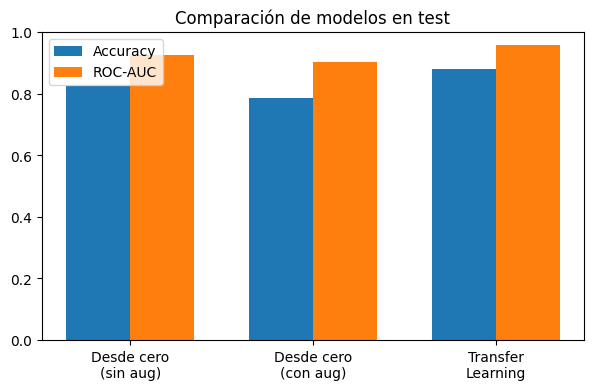

In [26]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)   | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)   | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

labels_plot = ["Desde cero\n(sin aug)", "Desde cero\n(con aug)", "Transfer\nLearning"]
accs = [test_acc, test_acc_aug, test_acc_tl]
aucs = [test_auc, test_auc_aug, test_auc_tl]

x = np.arange(len(labels_plot))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, accs, width, label="Accuracy")
plt.bar(x + width/2, aucs, width, label="ROC-AUC")
plt.xticks(x, labels_plot)
plt.ylim(0, 1)
plt.title("Comparación de modelos en test")
plt.legend()
plt.show()


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.

In [27]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


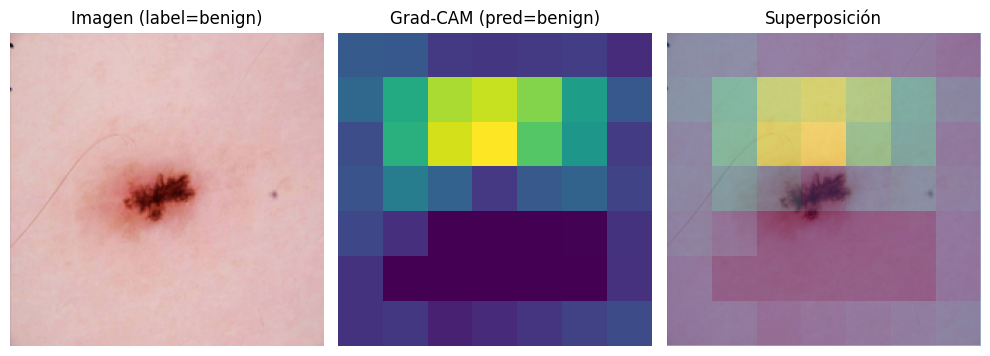

In [31]:
# Función para "desnormalizar" la imagen y poder visualizarla correctamente
def denormalize(img_tensor, mean=imagenet_mean, std=imagenet_std):
    img = img_tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = denormalize(x)
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title(f"Imagen (label={idx_to_class[int(y)]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={idx_to_class[pred_class]})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.imshow(cam, alpha=0.5, extent=(0, img.shape[1], img.shape[0], 0))
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


### 8.1. Calibración de probabilidades

Más allá de ver si el modelo acierta o no, en salud es importante saber si sus **probabilidades son confiables**: si el modelo dice "80% de probabilidad de malignidad", ¿realmente acierta cerca del 80% de las veces en ese grupo de casos? Esto se revisa con una **curva de calibración**, y se puede corregir con una técnica como **Platt Scaling** (ajustar las probabilidades con una regresión logística entrenada sobre las salidas del modelo).

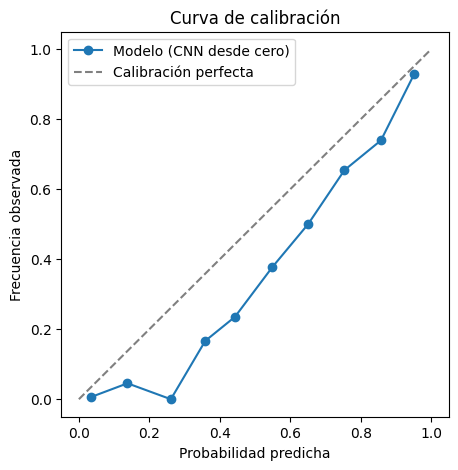

In [32]:
from sklearn.calibration import calibration_curve

# Usamos las predicciones de probabilidad del modelo base (model_scratch) en el set de test
_, _, y_true_cal, _, y_prob_cal, _ = evaluate(model_scratch, test_loader, criterion)

prob_true, prob_pred = calibration_curve(y_true_cal, y_prob_cal, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Modelo (CNN desde cero)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.title("Curva de calibración")
plt.legend()
plt.show()


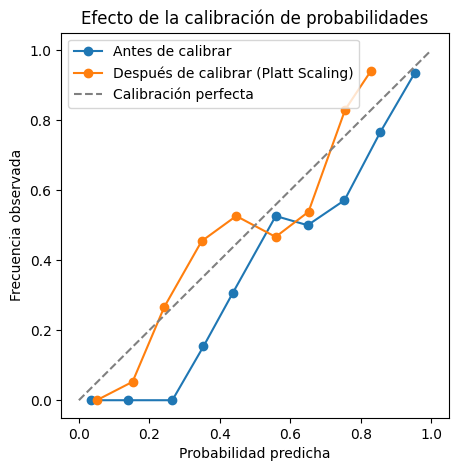

AUC antes de calibrar:   0.9366
AUC después de calibrar: 0.9366


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Dividimos de forma aleatoria y estratificada (mantiene la proporción de clases en ambos grupos)
prob_calib_fit, prob_calib_eval, y_calib_fit, y_calib_eval = train_test_split(
    y_prob_cal, y_true_cal,
    test_size=0.5,
    random_state=42,
    stratify=y_true_cal
)

prob_calib_fit = prob_calib_fit.reshape(-1, 1)
prob_calib_eval = prob_calib_eval.reshape(-1, 1)

calibrator = LogisticRegression()
calibrator.fit(prob_calib_fit, y_calib_fit)

prob_calibrated = calibrator.predict_proba(prob_calib_eval)[:, 1]

prob_true_before, prob_pred_before = calibration_curve(y_calib_eval, prob_calib_eval.ravel(), n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_calib_eval, prob_calibrated, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred_before, prob_true_before, marker="o", label="Antes de calibrar")
plt.plot(prob_pred_after, prob_true_after, marker="o", label="Después de calibrar (Platt Scaling)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia observada")
plt.title("Efecto de la calibración de probabilidades")
plt.legend()
plt.show()

print(f"AUC antes de calibrar:   {roc_auc_score(y_calib_eval, prob_calib_eval.ravel()):.4f}")
print(f"AUC después de calibrar: {roc_auc_score(y_calib_eval, prob_calibrated):.4f}")


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos (casos malignos).
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por tipo de piel, cámara/dermatoscopio usado, iluminación.
- Etiquetas ruidosas o dataset con procedencia poco documentada (frecuente en datasets de Kaggle).

4) Validación externa:
- Probar en datos de otra fuente (por ejemplo, HAM10000 o ISIC) es clave antes de confiar en el modelo.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.

## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.

In [34]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']